# 📈 Stock Market Movement Prediction

## 🎯 Objective
To analyze whether stock prices move UP or DOWN using technical indicators.

## 🧠 Idea
Markets are driven by momentum, trend, and volatility.
We explore whether these signals can help predict movement.

In [3]:
import numpy as np 
import pandas as pd

In [4]:
df=pd.read_csv("/Users/deepanshus/StockMarketPredictor/Project/data/Combined/all/1.csv")

In [5]:
df.head()

,rsi,macd,sma_ratio,volume_change,volatility,target
0,52.729384,5.231607,1.041503,-0.764616,0.015705,-0.009905
1,54.632972,5.343971,1.040495,-0.387146,0.015875,0.033691
2,68.850806,6.284495,1.044956,3.874652,0.015084,-0.028466
3,57.588533,6.152034,1.046341,-0.729922,0.018880,-0.012892
4,53.169572,5.627148,1.046767,-0.136228,0.019619,0.000297


## 📊 Initial Observations
- Dataset contains technical indicators
- No major missing values
- Data is structured and ready for validation

In [7]:
df.isnull().sum()


rsi               0
macd              0
sma_ratio        18
volume_change     0
volatility        0
target            0
dtype: int64

In [10]:
int(df.duplicated().sum())


1523

In [9]:
df.describe()

,rsi,macd,sma_ratio,volume_change,volatility,target
count,54125.000000,54125.000000,54107.000000,54125.000000,54125.000000,54125.000000
mean,51.628413,9.962524,1.015104,0.330461,0.044745,0.002844
std,15.830399,96.872625,0.069576,2.472523,0.048933,0.064409
min,0.903003,-1782.016877,0.634625,-0.993259,0.003050,-0.673552
25%,42.222222,-7.077906,0.974206,-0.312102,0.013683,-0.011455
50%,51.230007,0.941162,1.009412,-0.022152,0.022291,0.000473
75%,61.453078,15.786962,1.048099,0.416861,0.062351,0.013333
max,99.712919,2596.357192,2.032854,221.345748,0.448564,1.037695


## 🧹 Data Validation

Instead of heavy cleaning, we validate:
- Missing values
- Data consistency
- Valid ranges

This ensures reliability before analysis.

In [11]:
df['movement'] = (df['target'] > 0).astype(int)
df['movement'].value_counts()

movement
1    27626
0    26499
Name: count, dtype: int64

## 🎯 Defining the Problem

We convert returns into:
- 1 → UP
- 0 → DOWN

This transforms the task into classification.

## 🧠 Understanding Indicators

- RSI → momentum (overbought/oversold)
- MACD → trend strength
- SMA Ratio → trend alignment
- Volatility → market risk
- Volume Change → trading activity

In [12]:
df.corr()['target'].sort_values()

macd            -0.205279
rsi             -0.140928
sma_ratio       -0.105668
volume_change    0.006657
volatility       0.049568
movement         0.469826
target           1.000000
Name: target, dtype: float64

## 📉 Correlation Analysis

- MACD shows strongest relationship
- RSI has moderate influence
- Other features show weak correlation

👉 Suggests market is multi-factor driven

<Axes: >

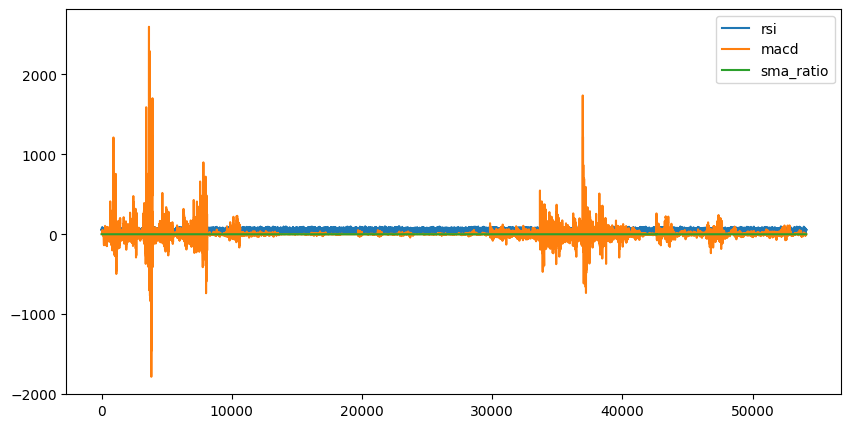

In [13]:
df[['rsi','macd','sma_ratio']].plot(figsize=(10,5))

## 📈 Indicator Behavior

- MACD → highly volatile
- RSI → stable range
- SMA Ratio → relatively flat

👉 MACD reacts faster to market changes

In [14]:
df.groupby('movement')[['rsi','macd','sma_ratio','volume_change','volatility']].mean()

,rsi,macd,sma_ratio,volume_change,volatility
movement,,,,,
0,52.624450,14.956797,1.016585,0.322462,0.043972
1,50.673009,5.171993,1.013683,0.338133,0.045486


## ⚔️ UP vs DOWN Analysis

- Higher MACD values → associated with downward movement
- Indicates trend exhaustion

👉 Market reversals after strong trends

In [15]:
df['rsi_zone'] = pd.cut(df['rsi'], bins=[0,30,70,100], labels=['Low','Neutral','High'])
df.groupby('rsi_zone')['movement'].mean()

/var/folders/g8/43rm_8rs5wbchfhhkxt_832c0000gn/T/ipykernel_92325/2773033070.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rsi_zone')['movement'].mean()


rsi_zone
Low        0.577971
Neutral    0.508006
High       0.477382
Name: movement, dtype: float64

## 🔥 RSI Zone Analysis

- Low RSI → higher probability of upward movement
- High RSI → lower probability

👉 Oversold → bounce
👉 Overbought → correction

In [16]:
df['rsi_macd'] = df['rsi'] * df['macd']
df['macd_sma'] = df['macd'] * df['sma_ratio']

## ⚠️ Note on Correlation

Correlation analysis is performed only on numerical features.
Categorical variables like RSI zones are analyzed separately using grouping methods.

In [18]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.corr()['target'].sort_values()

macd            -0.205279
macd_sma        -0.184827
rsi_macd        -0.171171
rsi             -0.140928
sma_ratio       -0.105668
volume_change    0.006657
volatility       0.049568
movement         0.469826
target           1.000000
Name: target, dtype: float64

## ⚙️ Interaction Features

We combine indicators to capture deeper relationships.

Result:
- Interaction features did not outperform MACD

👉 Simpler signals can be more powerful

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['rsi','macd','sma_ratio','volume_change','volatility']])

## ⚖️ Feature Scaling

Ensures all features contribute equally.

👉 Important for machine learning models

# 🧠 Final Conclusions

- Stock movement is driven by multiple factors
- MACD (trend) is the strongest indicator
- RSI helps identify reversal zones
- Interaction features add insight but not dominance
- Volume and volatility have limited impact

---

## 💬 Final Statement

Stock markets cannot be predicted using a single signal.
They require a combination of trend and momentum understanding.